In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from pathlib import Path

In [2]:
# Display Settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Folder to save charts for PowerPoint Presentation
OUT = Path("figs_whitehouse")
OUT.mkdir(exist_ok=True)

In [3]:
# Helper function to style plots consistently
def finalize(ax, title=None, xlabel=None, ylabel=None):
    ax.set_title(title or "", pad=12, fontsize=12, weight="bold")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

In [4]:
# Define file paths and load data
files = [
    Path("2023.01_WAVES-ACCESS-RECORDS.csv"),
    Path("2023.02_WAVES-ACCESS-RECORDS.csv"),
    Path("2023.03_WAVES-ACCESS-RECORDS.csv"),
    Path("2023.04_WAVES-ACCESS-RECORDS.csv"),
    Path("2023.05_WAVES-ACCESS-RECORDS.csv"),
]

# Read and combine into one DataFrame
dfs = [pd.read_csv(f) for f in files]
data = pd.concat(dfs, ignore_index=True)

# Preview Dataset
print("Dataset shape:", data.shape)
print("Columns:", list(data.columns))
data.head()

/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/2767960005.py:11: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]
/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/2767960005.py:11: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]
/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/2767960005.py:11: DtypeWarning: Columns (7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]


Dataset shape: (303374, 29)
Columns: ['Last Name', 'First Name', 'Middle Initial', 'UIN', 'BDGNBR', 'Access Type', 'TOA', 'POA', 'TOD', 'POD', 'Appointment Made Date', 'Appointment Start Date', 'Appointment End Date', 'Appointment Cancel Date', 'Total People', 'Last Updated By', 'POST', 'Last Entry Date', 'Terminal Suffix', 'Visitee Last Name', 'Visitee First Name', 'Meeting Location', 'Meeting Room', 'Caller Last Name', 'Caller First Name', 'CALLER_ROOM', 'RELEASEDATE', 'Caller Room', 'Release Date']


/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/2767960005.py:11: DtypeWarning: Columns (7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]
/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/2767960005.py:11: DtypeWarning: Columns (7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]


,Last Name,First Name,Middle Initial,UIN,BDGNBR,Access Type,TOA,POA,TOD,POD,Appointment Made Date,Appointment Start Date,Appointment End Date,Appointment Cancel Date,Total People,Last Updated By,POST,Last Entry Date,Terminal Suffix,Visitee Last Name,Visitee First Name,Meeting Location,Meeting Room,Caller Last Name,Caller First Name,CALLER_ROOM,RELEASEDATE,Caller Room,Release Date
0,AABYE,MARY,A,U13230,197546.0,VA,Jan 19 2023 8:58AM,NaN,NaN,B04,1/5/2023 17:16,1/19/2023 9:00,1/19/2023 23:59,NaN,5,DE,WIN,1/5/2023 18:07,DE,Epstein,Diana,OEOB,Bowling Alley - 037,EPSTEIN,DIANA,NaN,4/30/2023,NaN,NaN
1,AALST,CARLO,B,U10746,NaN,VA,Jan 3 2023 9:37AM,NaN,NaN,NaN,12/27/2022 1:33,1/3/2023 9:30,1/3/2023 23:59,NaN,2,VW,WIN,12/27/2022 5:57,VW,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,4/30/2023,NaN,NaN
2,AARONSON,SCOTT,I,U21068,201034.0,VA,Jan 31 2023 10:42AM,NaN,NaN,D03,1/30/2023 22:27,1/31/2023 10:45,1/31/2023 23:59,NaN,3,PK,WIN,1/31/2023 5:32,PK,Durkovich,Caitlin,OEOB,425,KHAN,PUNEET,NaN,4/30/2023,NaN,NaN
3,ABAD,JOHN,C,U11018,NaN,VA,NaN,NaN,NaN,NaN,12/28/2022 2:04,1/4/2023 10:00,1/4/2023 23:59,NaN,1,VW,WIN,12/28/2022 8:10,VW,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,4/30/2023,NaN,NaN
4,ABADIE,NATHAN,D,U15945,NaN,VA,Jan 21 2023 9:46AM,NaN,NaN,NaN,1/14/2023 1:33,1/21/2023 9:30,1/21/2023 23:59,NaN,17,VW,WIN,1/14/2023 12:56,VW,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,4/30/2023,NaN,NaN


In [5]:
# Data Preprocessing
data["TOA"] = pd.to_datetime(data["TOA"], errors="coerce")  # Parse time of arrival 

# Extract time features
data["date"] = data["TOA"].dt.date
data["month"] = data["TOA"].dt.to_period("M")
data["day_of_week"] = data["TOA"].dt.day_name()
data["hour"] = data["TOA"].dt.hour

# Keep relevant columns
keep_cols = ["TOA", "date", "month", "day_of_week", "hour", 
             "Total People", "Meeting Location", "Meeting Room"]
visits_df = data[keep_cols].copy()

# Drop rows with missing date
visits_df = visits_df.dropna(subset=["date"]).copy()

# Convert 'date' to datetime datatype
visits_df["date"] = pd.to_datetime(visits_df["date"], errors="coerce")

# Preview visits DataFrame
display(visits_df.dtypes)
visits_df.head()

TOA                 datetime64[ns]
date                datetime64[ns]
month                    period[M]
day_of_week                 object
hour                       float64
Total People                 int64
Meeting Location            object
Meeting Room                object
dtype: object

,TOA,date,month,day_of_week,hour,Total People,Meeting Location,Meeting Room
0,2023-01-19 08:58:00,2023-01-19,2023-01,Thursday,8.0,5,OEOB,Bowling Alley - 037
1,2023-01-03 09:37:00,2023-01-03,2023-01,Tuesday,9.0,2,WH,EW TOUR
2,2023-01-31 10:42:00,2023-01-31,2023-01,Tuesday,10.0,3,OEOB,425
4,2023-01-21 09:46:00,2023-01-21,2023-01,Saturday,9.0,17,WH,EW TOUR
5,2023-01-04 10:21:00,2023-01-04,2023-01,Wednesday,10.0,1,WH,EW TOUR


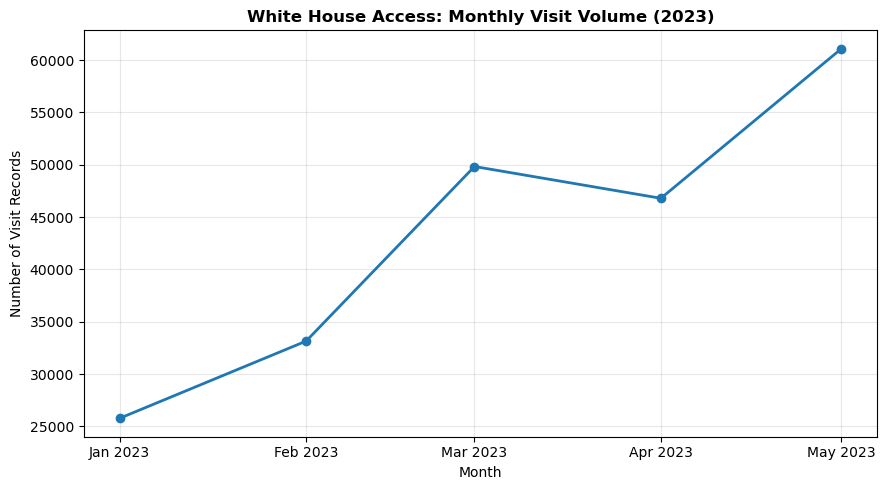

In [6]:
# Visual 1: Monthly Visits Trend - Line Chart
 
# Count total visits per month 
monthly_visits = (visits_df.groupby("month").size()
    .rename("visits").reset_index()
)

# Convert Period[M] to timestamp for plot
monthly_visits["month_ts"] = monthly_visits["month"].dt.to_timestamp()

# Plot line chart for monthly visit volume
plt.figure(figsize=(9,5))
ax = plt.gca()
ax.plot(
    monthly_visits["month_ts"],
    monthly_visits["visits"],
    marker="o", linewidth=2
)

# Format x-axis as months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Titles and Labels
ax.set_title("White House Access: Monthly Visit Volume (2023)", fontsize=12, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Visit Records")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and display plot
plt.savefig(Path("figs_whitehouse") / "v1_monthly_visits.png", dpi=200)
plt.show()

/var/folders/sn/3bh7n78n6cj225l2xk4bhctr0000gn/T/ipykernel_12669/681174740.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


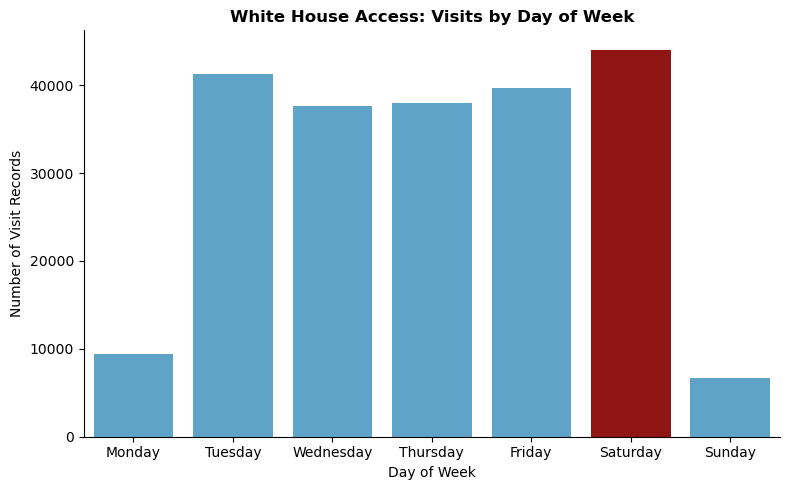

In [7]:
# Visual 2: Visits by Day of Week - Bar Chart

# Aggregate visits by day of week (dow)
dow_counts = (
    visits_df["day_of_week"].value_counts()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

# Find busiest day
busiest_day = dow_counts.idxmax()

# Add color to busiest day
colors = ["#4DA8DA" if day != busiest_day else "#A30000" for day in dow_counts.index]

# Plot bar chart
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=dow_counts.index, 
    y=dow_counts.values, 
    palette=colors
)

# Titles and labels
ax.set_title("White House Access: Visits by Day of Week", fontsize=12, weight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Visit Records")
sns.despine()
plt.tight_layout()

# Save and display plot
plt.savefig(Path("figs_whitehouse") / "v2_dayofweek_visits.png", dpi=200)
plt.show()

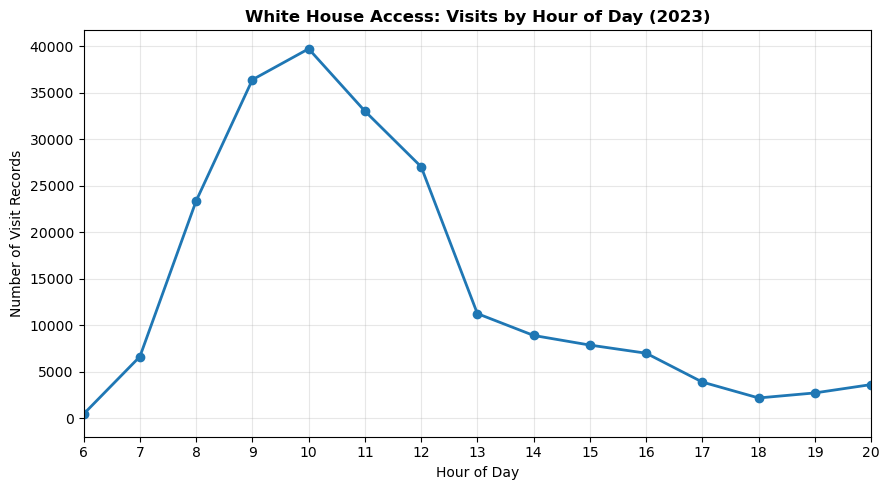

In [8]:
# Visual 3: Visits by Hour Per Day - Line Chart

# Group by hour
hourly_visits = (
    visits_df.groupby("hour").size()
    .rename("visits")
    .reset_index()
)
# Plot line chart hourly visits
plt.figure(figsize=(9,5))
ax = plt.gca()
ax.plot(
    hourly_visits["hour"],
    hourly_visits["visits"],
    marker="o", linewidth=2
)

# Titles and Lables
ax.set_title("White House Access: Visits by Hour of Day (2023)", fontsize=12, weight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Visit Records")
ax.set_xticks(range(6, 24))  # shows all 24 hours

# Limit x-axis to only 'prime time' hours (6am - 8pm)
ax.set_xlim(6, 20)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and display
plt.savefig(Path("figs_whitehouse") / "v3_hourly_visits.png", dpi=200)
plt.show()

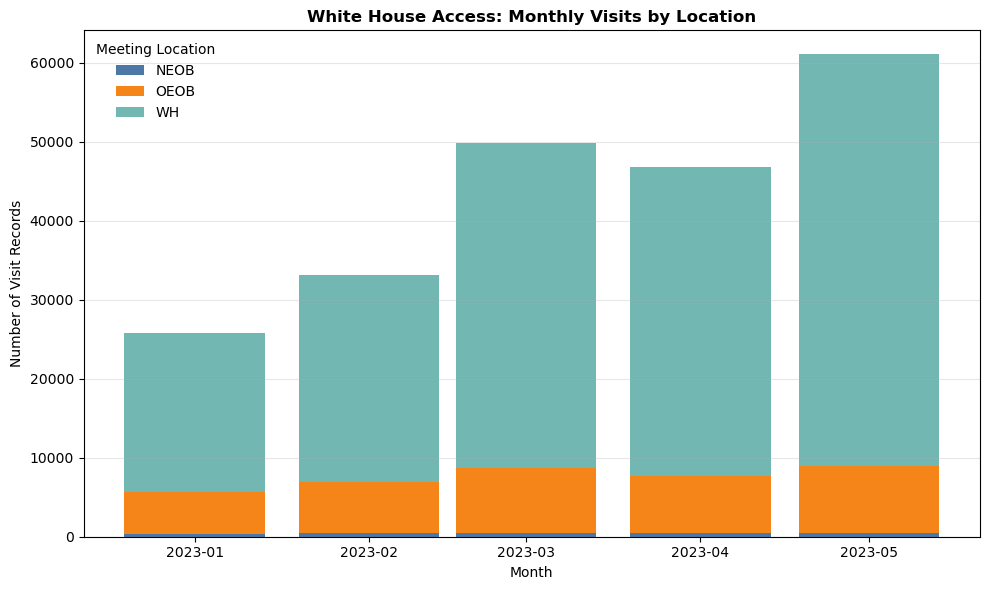

In [9]:
# Visual 4: Monthly visits by location - Stacked Bar Chart

# pick top locations, everything else -> 'other'
top_locs = (
    visits_df["Meeting Location"].fillna("Unknown")
    .value_counts().head(3).index.tolist()
)
tmp = visits_df.copy()
tmp["loc_group"] = tmp["Meeting Location"].fillna("Unknown")
tmp.loc[~tmp["loc_group"].isin(top_locs), "loc_group"] = "Other"

# month x location table
loc_month = (
    tmp.groupby(["month", "loc_group"]).size()
       .unstack(fill_value=0).sort_index()
)

# x as timestamps for plotting; width in days
x = loc_month.index.to_timestamp()
bar_width_days = 25 # width of each bar in days

# Plot stacked bar
plt.figure(figsize=(10,6))
ax = plt.gca()

bottom = [0] * len(loc_month)
palette = ["#4C78A8", "#F58518", "#72B7B2"]  # colors: blue, orange, teal

for i, col in enumerate(loc_month.columns):
    heights = loc_month[col].values.tolist()
    ax.bar(x, heights, bottom=bottom, width=bar_width_days,
           label=col, color=palette[i % len(palette)], align="center")
    # update bottom for next stack
    bottom = [b + h for b, h in zip(bottom, heights)]

# Titles and Labels
ax.set_title("White House Access: Monthly Visits by Location", fontsize=12, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Visit Records")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Meeting Location", frameon=False)
plt.tight_layout()
# Save and display
plt.savefig(Path("figs_whitehouse") / "v4_stacked_by_location.png", dpi=200)
plt.show()

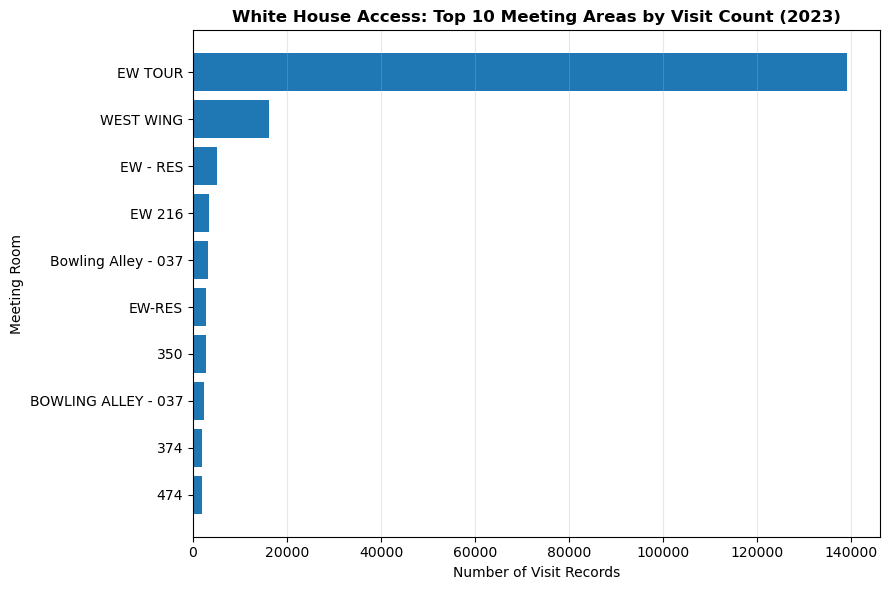

In [10]:
# Visual 5: Top Meeting Rooms - Horizontal Bar Chart

# Count visits per meeting room 
room_counts = (
    visits_df["Meeting Room"].fillna("Unknown") # fill nulls with 'unknown'
    .value_counts().head(10).sort_values(ascending=True)
)
# Plot Bar chart 
plt.figure(figsize=(9,6))
ax = plt.gca()
ax.barh(room_counts.index, room_counts.values)

# Titles and Labels
ax.set_title("White House Access: Top 10 Meeting Areas by Visit Count (2023)",
             fontsize=12, weight="bold")
ax.set_xlabel("Number of Visit Records")
ax.set_ylabel("Meeting Room")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()

# Save and display
plt.savefig(Path("figs_whitehouse") / "v5_top_meeting_rooms.png", dpi=200)
plt.show()

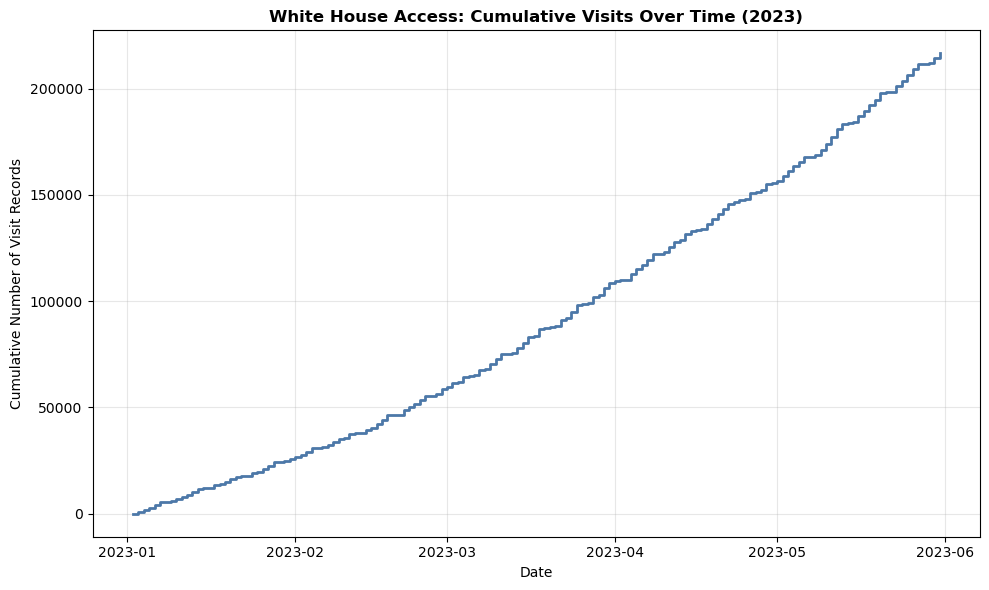

In [11]:
# Visual 6: Cumulative Visits Over Time - Step Chart

# Count cumulative visits by date
daily_visits = (
    visits_df.groupby("date").size()
    .rename("visits").reset_index()
    .sort_values("date")
)

daily_visits["cumulative_visits"] = daily_visits["visits"].cumsum()

# Plot step chart
plt.figure(figsize=(10,6))
ax = plt.gca()
ax.step(
    daily_visits["date"],
    daily_visits["cumulative_visits"],
    where="post",
    linewidth=2,
    color="#4C78A8"
)
# Titles and Lables
ax.set_title("White House Access: Cumulative Visits Over Time (2023)", fontsize=12, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Number of Visit Records")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and display
plt.savefig(Path("figs_whitehouse") / "v6_cumulative_visits.png", dpi=200)
plt.show()